# Random Forest Multiclass Classification

This notebook implements a complete machine learning pipeline for multiclass classification of coronary artery stenosis using Random Forest.

## Execution Order:
1. **Imports**: Load all required libraries
2. **Load Dataset**: Import and prepare the raw data
3. **Data Cleaning & Preprocessing**: Clean data, handle missing values, and prepare features
4. **Grid Search** (Optional): Optimize hyperparameters via cross-validation
5. **Model Training**: Train Random Forest classifier with SMOTE and feature selection
6. **Overfitting Check**: Compare training vs. test performance
7. **Model Evaluation**: Comprehensive evaluation metrics and confusion matrix
8. **ROC & PR Curves**: Visualize model performance across classes
9. **Feature Importance**: Identify most important features


## 1. Imports

This cell imports all necessary libraries for data manipulation, preprocessing, model training, and evaluation. Key libraries include:
- **pandas/numpy**: Data manipulation and numerical operations
- **sklearn**: Machine learning tools (preprocessing, feature selection, metrics, cross-validation)
- **sklearn.ensemble**: Random Forest classifier
- **imblearn**: SMOTE for handling class imbalance
- **matplotlib**: Visualization


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    recall_score, precision_score, f1_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from scipy.sparse import issparse



## 2. Load Dataset

This cell loads the CSV dataset and performs initial data preparation:
- Reads the CSV file with semicolon separator
- Converts European number format (commas to dots)
- Automatically converts numeric columns to appropriate data types
- Separates features (X) from the target variable (y = OUTCOME_3Kat_KHK)
- The target has 3 classes: 0 (No Stenosis), 1 (Non-significant stenosis), 2 (Significant Stenosis)


In [2]:
data = pd.read_csv(
    'T49.2_Sep2025_1_StGallen.csv',
    sep=';',
    na_values=["", " ", "NA", "N/A", "NULL"]
)

data = data.replace(",", ".", regex=True)

for col in data.columns:
    temp = pd.to_numeric(data[col], errors="coerce")
    if temp.notna().sum() == len(data[col]):
        data[col] = temp

data = data.apply(pd.to_numeric, errors='ignore')

X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"]



/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_91454/4242163872.py:1: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(
/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_91454/4242163872.py:14: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors='ignore')


## 3. Data Cleaning & Preprocessing

This cell performs comprehensive data cleaning and preprocessing:

**Data Cleaning:**
- Removes dependent variables (e.g., LDL, HDL, cholesterol components) that are directly derived from other features
- Identifies categorical and numerical features
- Removes highly correlated features (correlation > 0.95) to reduce redundancy and prevent multicollinearity

**Train/Test Split:**
- Splits data into 75% training and 25% test set (as specified in the paper)
- Uses stratified split to maintain class distribution in both sets

**Preprocessing Pipeline:**
- **Categorical features**: Most frequent imputation + One-Hot Encoding
- **Numerical features**: kNN Imputation (k=5) + MinMax Scaling (normalizes to [0,1])
- Falls back to IterativeImputer or Median imputation if kNN fails
- Fits preprocessor on training data and transforms both training and test sets
- Converts sparse matrices to dense arrays for compatibility with Random Forest


In [3]:
columns_to_drop = [
    "remnantCholesterol0_corr", "ldl0_mmol", "hdl0_mmol",
    "triglyc0_mmol", "cholest0_mmol", "LDL_0_apo_B_ratio", "BONE_KAT"
]
data = data.drop(columns_to_drop, axis=1)

manual_categorical = [
    "geschlecht", "currsmo0", "diabetes_ADA_final_0",
    "ANY_OPE", "ANY_OPO",
    "Osteoporos_inkl_Osteopenie_T_Wert_abhängig",
    "Osteoporose_T_Wert_abhängig"
]

for col in manual_categorical:
    if col in data.columns:
        data[col] = data[col].astype(str)

X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
numerical_features = [col for col in numerical_features if col not in categorical_features]

print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")

if len(numerical_features) > 0:
    X_num = X[numerical_features].select_dtypes(include=['float64', 'int64'])
    if len(X_num.columns) > 0:
        corr_matrix = X_num.corr().abs()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        to_remove = set()
        for column in upper_triangle.columns:
            high_corr = upper_triangle.index[upper_triangle[column] > 0.95].tolist()
            if high_corr:
                for col in high_corr:
                    if column not in to_remove:
                        to_remove.add(col)
        
        if len(to_remove) > 0:
            print(f"Removing {len(to_remove)} highly correlated features")
            X = X.drop(columns=list(to_remove), errors='ignore')
            numerical_features = [f for f in numerical_features if f not in to_remove]

print(f"After cleaning - Numerical: {len(numerical_features)}, Categorical: {len(categorical_features)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

cat_preprocessor = SklearnPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

try:
    num_preprocessor = SklearnPipeline(steps=[
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", MinMaxScaler())
    ])
    print("Using KNNImputer + MinMaxScaler")
except:
    try:
        num_preprocessor = SklearnPipeline(steps=[
            ("imputer", IterativeImputer(random_state=42, max_iter=10)),
            ("scaler", MinMaxScaler())
        ])
        print("Using IterativeImputer + MinMaxScaler (fallback)")
    except:
        num_preprocessor = SklearnPipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler())
        ])
        print("Using Median Imputer + MinMaxScaler (fallback)")

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_preprocessor, categorical_features),
        ("num", num_preprocessor, numerical_features)
    ],
    remainder="passthrough"
)

preprocessor.fit(X_train, y_train)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

if issparse(X_train_transformed):
    X_train_transformed = X_train_transformed.toarray()
if issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

print(f"\nTransformed shapes:")
print(f"  Training: {X_train_transformed.shape}")
print(f"  Test: {X_test_transformed.shape}")



Categorical features: 7
Numerical features: 634
Removing 428 highly correlated features
After cleaning - Numerical: 206, Categorical: 7
Using KNNImputer + MinMaxScaler

Transformed shapes:
  Training: (1732, 224)
  Test: (578, 224)


## 4. Build Pipeline

This cell builds and trains the Random Forest model with the complete pipeline:

**Process:**
1. Performs feature selection (SelectKBest with mutual information, k=100)
2. Applies SMOTE oversampling to handle class imbalance
3. Trains Random Forest classifier with optimized hyperparameters
4. Performs 5-fold cross-validation to assess model performance
5. Makes predictions on test set

**Hyperparameters:**
- Optimized for balanced performance across all classes
- Uses class_weight='balanced' to handle class imbalance
- Regularization through max_depth and min_samples_split


In [4]:
np.random.seed(42)

K_FEATURES = 100
SMOTE_K_NEIGHBORS = 3

class_counts = pd.Series(y_train).value_counts().sort_index()
print(f"Class distribution:")
for cls, count in class_counts.items():
    class_name = {0: "No Stenosis", 1: "Non-significant stenosis", 2: "Significant Stenosis"}.get(cls, f"Class {cls}")
    pct = count / len(y_train) * 100
    print(f"  {class_name} (Class {cls}): {count} samples ({pct:.1f}%)")

print(f"\nMethods:")
print(f"  1. kNN Imputation + MinMax Scaling")
print(f"  2. 75:25 Train/Test Split")
print(f"  3. SMOTE Oversampling (k_neighbors={SMOTE_K_NEIGHBORS})")
print(f"  4. Feature Selection (k={K_FEATURES})")
print(f"  5. Random Forest with class_weight='balanced'")

pipeline = Pipeline([
    ("feature_selection", SelectKBest(mutual_info_classif, k=K_FEATURES)),
    ("smote", SMOTE(random_state=42, k_neighbors=SMOTE_K_NEIGHBORS, sampling_strategy='auto')),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

print(f"\nTraining model...")
pipeline.fit(X_train_transformed, y_train)

feature_selector = pipeline.named_steps['feature_selection']
selected_features_mask = feature_selector.get_support()
X_train_selected = X_train_transformed[:, selected_features_mask]
X_test_selected = X_test_transformed[:, selected_features_mask]

print(f"\nFeature Selection:")
print(f"   Selected {X_train_selected.shape[1]} features out of {X_train_transformed.shape[1]}")

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train_transformed, y_train, cv=cv_strategy, scoring='balanced_accuracy')
print(f"\nCross-Validation Results:")
print(f"   Mean Balanced Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

y_pred = pipeline.predict(X_test_transformed)
y_proba = pipeline.predict_proba(X_test_transformed)

print(f"\nModel training completed!")



Class distribution:
  No Stenosis (Class 0): 272 samples (15.7%)
  Non-significant stenosis (Class 1): 474 samples (27.4%)
  Significant Stenosis (Class 2): 986 samples (56.9%)

Methods:
  1. kNN Imputation + MinMax Scaling
  2. 75:25 Train/Test Split
  3. SMOTE Oversampling (k_neighbors=3)
  4. Feature Selection (k=100)
  5. Random Forest with class_weight='balanced'

Training model...

Feature Selection:
   Selected 100 features out of 224

Cross-Validation Results:
   Mean Balanced Accuracy: 0.4690 (+/- 0.0225)

Model training completed!


## 5. Model Evaluation

This cell performs comprehensive model evaluation:
- Calculates classification metrics (accuracy, balanced accuracy, precision, recall, F1)
- Generates confusion matrix
- Provides per-class performance metrics
- Evaluates model performance on the test set


MODEL EVALUATION

Overall Accuracy: 0.5865
Balanced Accuracy: 0.5154
Mean CV Balanced Accuracy: 0.4690

Classification Report:
                          precision    recall  f1-score   support

             No Stenosis       0.41      0.55      0.47        91
Non-significant stenosis       0.43      0.23      0.30       158
    Significant Stenosis       0.68      0.77      0.72       329

                accuracy                           0.59       578
               macro avg       0.51      0.52      0.50       578
            weighted avg       0.57      0.59      0.57       578


Confusion Matrix:


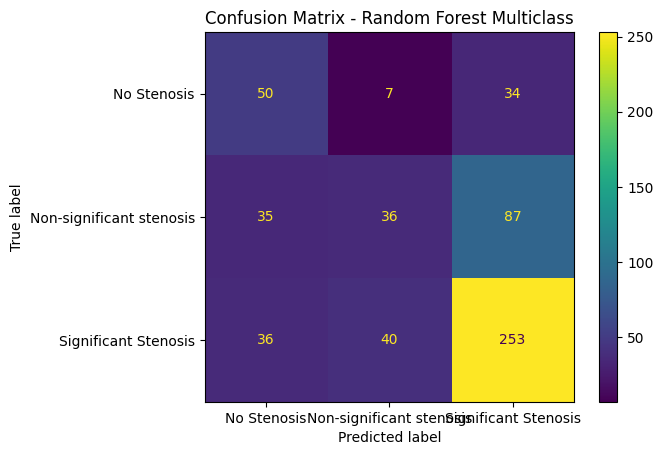


Per-Class Recall:
  No Stenosis (Class 0): 0.5495
  Non-significant stenosis (Class 1): 0.2278
  Significant Stenosis (Class 2): 0.7690


In [5]:
print("=" * 80)
print("MODEL EVALUATION")
print("=" * 80)

accuracy = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print(f"\nOverall Accuracy: {accuracy:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"Mean CV Balanced Accuracy: {cv_scores.mean():.4f}")

print("\n" + "=" * 80)
print("Classification Report:")
print("=" * 80)
print(classification_report(y_test, y_pred, target_names=["No Stenosis", "Non-significant stenosis", "Significant Stenosis"]))

print("\n" + "=" * 80)
print("Confusion Matrix:")
print("=" * 80)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Stenosis", "Non-significant stenosis", "Significant Stenosis"]).plot()
plt.title("Confusion Matrix - Random Forest Multiclass")
plt.show()

recall_class2 = recall_score(y_test, y_pred, labels=[2], average=None)[0]
recall_class0 = recall_score(y_test, y_pred, labels=[0], average=None)[0]
recall_class1 = recall_score(y_test, y_pred, labels=[1], average=None)[0]

print(f"\nPer-Class Recall:")
print(f"  No Stenosis (Class 0): {recall_class0:.4f}")
print(f"  Non-significant stenosis (Class 1): {recall_class1:.4f}")
print(f"  Significant Stenosis (Class 2): {recall_class2:.4f}")



## 6. Overfitting Check

This cell compares training and test set performance to detect overfitting:
- Calculates metrics on both training and test sets
- Compares balanced accuracy, recall, and overall accuracy
- Identifies performance gaps that indicate overfitting
- Helps validate model generalization


In [ ]:
y_pred_train = pipeline.predict(X_train_transformed)

train_recall_class2 = recall_score(y_train, y_pred_train, labels=[2], average=None)[0]
test_recall_class2 = recall_score(y_test, y_pred, labels=[2], average=None)[0]

train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
test_bal_acc = balanced_accuracy_score(y_test, y_pred)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred)

print("=" * 80)
print("OVERFITTING CHECK - Prioritizing Recall for Significant Stenosis (Class 2)")
print("=" * 80)
print(f"\n⭐ Recall (Significant Stenosis - Class 2) ⭐")
print(f"  Training: {train_recall_class2:.4f}")
print(f"  Test:     {test_recall_class2:.4f}")
print(f"  Gap:      {train_recall_class2 - test_recall_class2:.4f}")
print()
print(f"Balanced Accuracy:")
print(f"  Training: {train_bal_acc:.4f}")
print(f"  Test:     {test_bal_acc:.4f}")
print(f"  Gap:      {train_bal_acc - test_bal_acc:.4f}")
print()
print(f"Regular Accuracy:")
print(f"  Training: {train_acc:.4f}")
print(f"  Test:     {test_acc:.4f}")
print(f"  Gap:      {train_acc - test_acc:.4f}")
print()

gap_recall = train_recall_class2 - test_recall_class2
gap_bal = train_bal_acc - test_bal_acc
gap_acc = train_acc - test_acc

if gap_recall > 0.15 or gap_bal > 0.15:
    print("⚠️  WARNING: Large gap detected - model may be overfitting!")
    print("   Consider: stronger regularization, fewer features, or simpler model")
elif gap_recall > 0.10 or gap_bal > 0.10:
    print("⚠️  CAUTION: Moderate gap detected - monitor for overfitting")
else:
    print("✓ Model shows good generalization (small gap between train/test)")
    print(f"  ✓ Recall gap (Class 2): {gap_recall:.4f} (good)")
    print(f"  ✓ Balanced accuracy gap: {gap_bal:.4f} (good)")



## 7. ROC and Precision-Recall Curves

This cell visualizes model performance with multiclass ROC and Precision-Recall curves:
- Plots ROC curves for each class (One-vs-Rest approach)
- Plots Precision-Recall curves for each class
- Shows AUC and Average Precision for each class
- Provides visual assessment of model performance across all classes


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

clf = pipeline.named_steps["classifier"]
classes = clf.classes_

class_names = {
    0: "No Stenosis",
    1: "Non-significant stenosis",
    2: "Significant Stenosis"
}

Y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{class_names[cls]} (AUC={roc_auc:.2f})")

ax.plot([0, 1], [0, 1], linestyle=":", lw=1, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Random Forest Multiclass Classification")
ax.legend(loc="lower right")

ax = axes[1]
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(Y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(Y_test_bin[:, i], y_proba[:, i])
    ax.plot(recall, precision, lw=2, label=f"{class_names[cls]} (AP={ap:.2f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curves — Random Forest Multiclass Classification")
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()



## 8. Feature Importance

This cell identifies and visualizes the most important features:
- Extracts feature importance from the trained Random Forest model
- Maps feature names to selected features
- Plots top 15 most important features
- Helps understand which features drive model predictions


In [ ]:
feature_importances = pipeline.named_steps['classifier'].feature_importances_
selected_feature_names = preprocessor.get_feature_names_out()[selected_features_mask]

importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'].values)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances - Random Forest Multiclass')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



## 9. Grid Search (Optional)

This cell performs hyperparameter optimization using GridSearchCV:
- Searches over a grid of hyperparameters
- Uses cross-validation to evaluate parameter combinations
- Finds optimal hyperparameters for the Random Forest classifier
- Can be skipped if using default parameters from the pipeline cell

**Note:** Grid Search can be computationally expensive. Consider using RandomizedSearchCV for faster results.


In [ ]:
use_grid_search = False

if use_grid_search:
    param_grid = {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [8, 10, 12, None],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__max_features': ['sqrt', 'log2']
    }

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='balanced_accuracy',
        n_jobs=-1,
        verbose=2
    )

    print("Starting Grid Search...")
    grid_search.fit(X_train_transformed, y_train)

    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.4f}")

    best_pipeline = grid_search.best_estimator_
    y_pred = best_pipeline.predict(X_test_transformed)
    y_proba = best_pipeline.predict_proba(X_test_transformed)
else:
    print("Grid Search skipped. Using default parameters.")

